# Delay Prediction (Model 3 : Balanced Random Forest en cascade)

---

## Pourquoi Balanced Random Forest ?

Le **Balanced Random Forest (BRF)** est une variante de Random Forest conçue spécifiquement pour les  
déséquilibres extrêmes. À chaque arbre, il applique un **under-sampling aléatoire de la classe majoritaire**  
pour que chaque arbre s'entraîne sur un dataset équilibré, sans générer de données synthétiques.

### Architecture : Cascade ordonnée à 3 étapes binaires

```
Étape 1 — BRF Binaire : Retard > 5 min ?        
Étape 2 — BRF Binaire : Parmi >5min, >30min ?   
Étape 3 — BRF Binaire : Parmi >30min, >60min ?  
```

### Comparaison avec Logistic regression et LightGBM

| Critère | **Logistic Regression** | **BRF** | **LightGBM** |
|---|---|---|---|
| Type de modèle | Linéaire | Ensemble (bagging) | Ensemble (boosting) |
| Gestion déséquilibre | `class_weight='balanced'` | Under-sampling par arbre | `scale_pos_weight` |
| Vitesse | Très rapide | Lent | Rapide |
| Interprétabilité | Excellente (coefficients) | Bonne | Bonne (SHAP) |
| Relations non-linéaires | ✗ (ne les capte pas) | ✓ | ✓ |
| Rôle ici | **Baseline de référence** | Modèle principal | Challenger |


### Règles métier (Système NS — Pays-Bas)

| Classe | Retard | Action | Compensation |
|---|---|---|---|
| 0 | ≤ 5 min | Rien | — |
| 1 | 5–30 min | Alertes passagers | — |
| 2 | 30–60 min | Compensation légale | **50% du prix du billet** |
| 3 | > 60 min | Compensation légale | **100% du prix du billet** |

---
## 1. Imports et Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, re
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
    print('✓ imbalanced-learn disponible')
    print('  → BalancedRandomForestClassifier activé')
    print('  → SMOTE disponible (optionnel pour étape 2)')
except ImportError:
    IMBLEARN_AVAILABLE = False
    print('✗ imbalanced-learn NON installé')
    print('  REQUIS pour ce notebook : pip install imbalanced-learn')
    raise ImportError('Installe imbalanced-learn : pip install imbalanced-learn')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = sns.color_palette('muted')

print('\nImports OK.')

✓ imbalanced-learn disponible
  → BalancedRandomForestClassifier activé
  → SMOTE disponible (optionnel pour étape 2)

Imports OK.


---
## 2. Chargement et Prétraitement

In [4]:
df_clean = pd.read_csv('df_clean.csv', low_memory=False)
print(f'Chargé : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')

df_clean['Service:Date']        = pd.to_datetime(df_clean['Service:Date'], errors='coerce')
df_clean['Stop:Departure time'] = pd.to_datetime(df_clean['Stop:Departure time'], utc=True, errors='coerce')
df_clean['Stop:Arrival time']   = pd.to_datetime(df_clean['Stop:Arrival time'],   utc=True, errors='coerce')
df_clean['dep_hour'] = df_clean['Stop:Departure time'].dt.tz_convert('Europe/Amsterdam').dt.hour

for col in ['Stop:Platform change','Service:Completely cancelled','Service:Partly cancelled',
            'Stop:Arrival cancelled','Stop:Departure cancelled']:
    if col in df_clean.columns:
        df_clean[col] = (df_clean[col].astype(str).str.strip().str.lower()
                         .map({'true':1,'false':0,'1':1,'0':0}).fillna(0).astype(int))

df_clean['Service:Maximum delay'] = pd.to_numeric(df_clean['Service:Maximum delay'], errors='coerce')
print('Prétraitement OK.')

Chargé : 21,838,516 lignes × 17 colonnes
Prétraitement OK.


In [25]:
print(df_clean['Service:Type'].value_counts())

Service:Type
Sprinter             10000026
Stoptrein             5184571
Intercity             4630662
Sneltrein              737298
Stopbus ipv trein      519260
Intercity direct       283270
Snelbus ipv trein      234374
Eurostar                64014
Metro ipv trein         59362
ICE International       47644
Nightjet                23314
Speciale Trein          16010
Extra trein             13946
Taxibus ipv trein       10295
EuroCity                 5401
Eurocity Direct          3651
European Sleeper         3407
Nachttrein               1607
Bus                       312
Int. Trein                 68
Belbus                     18
Stoomtrein                  6
Name: count, dtype: int64


---
## 3. Estimation du Prix du Billet par Service

Le prix d'un billet NS varie selon la durée du trajet.  
Après analyse des tarifs officiels NS 2024, nous avons estimé un prix moyen du billet pour chaque tranche de durée de service:

| Durée du service | Prix estimé |
|---|---|
| < 15 min (trajet très court) | €5 |
| 15–30 min | €8 |
| 30–60 min | €14 |
| 60–90 min | €22 |
| 90–120 min | €30 |
| > 120 min | €40 |


> **Note** : Ces estimations sont basées sur des recherches sur le réseau NS (train intercités néerlandais).  
> Le prix est estimé **par service** (trajet complet), pas par stop individuel.
> La durée du service = (heure d'arrivée au dernier stop) - (heure de départ au premier stop).

═════════════════════════════════════════════════════════════════
  DISTRIBUTION DES PRIX DE BILLETS ESTIMÉS (par service)
═════════════════════════════════════════════════════════════════
  €    5  →   300,297 services  ( 14.6%)
  €    8  →   388,655 services  ( 18.8%)
  €   14  →   743,298 services  ( 36.0%)
  €   22  →   260,275 services  ( 12.6%)
  €   30  →   172,842 services  (  8.4%)
  €   40  →   197,895 services  (  9.6%)
─────────────────────────────────────────────────────────────────
  Prix moyen   : €16.40
  Prix médian  : €14.00
  Durée moy.   : 53.9 min
═════════════════════════════════════════════════════════════════


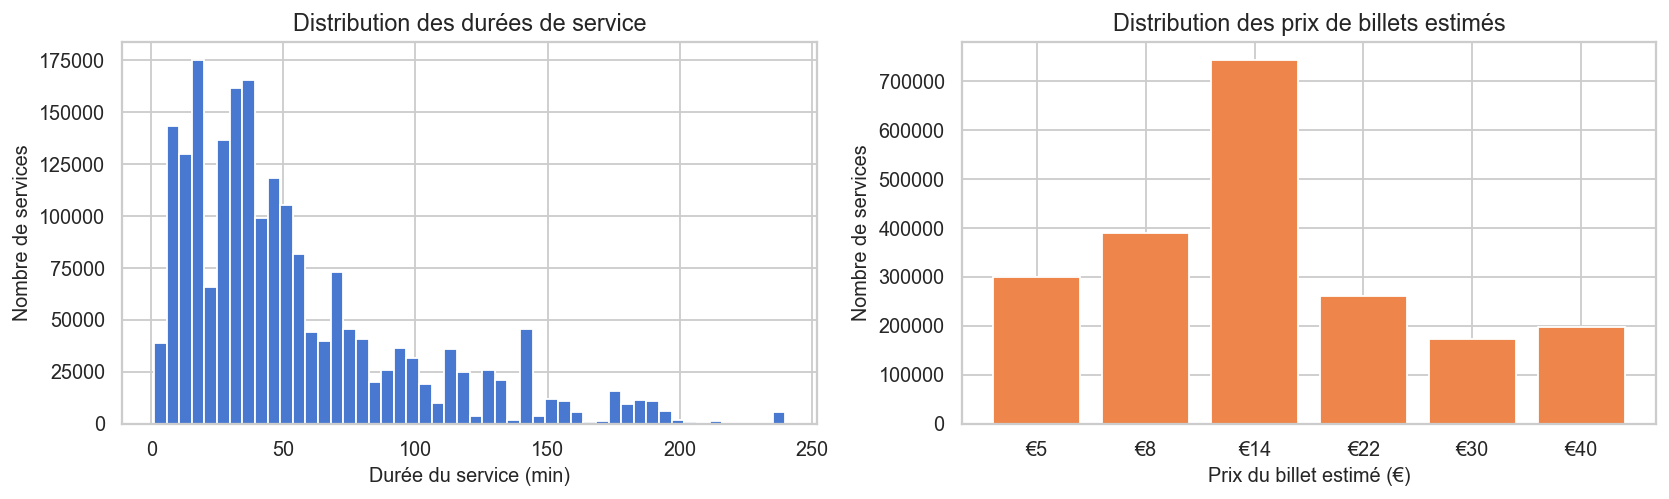

In [ ]:

df_times = df_clean[['Service:RDT-ID', 'Stop:Departure time', 'Stop:Arrival time']].copy()
df_times = df_times.dropna(subset=['Stop:Departure time', 'Stop:Arrival time'])

df_service_duration = df_times.groupby('Service:RDT-ID').agg(
    first_dep = ('Stop:Departure time', 'min'),
    last_arr  = ('Stop:Arrival time',   'max')
).reset_index()

df_service_duration['service_duration_min'] = (
    (df_service_duration['last_arr'] - df_service_duration['first_dep'])
    .dt.total_seconds() / 60
)

df_service_duration = df_service_duration[
    (df_service_duration['service_duration_min'] > 0) &
    (df_service_duration['service_duration_min'] < 480)
].copy()

def estimate_ticket_price(duration_min):
    """
    Estimation du prix d'un billet NS (2ème classe, 1 personne)
    basée sur la durée totale du service.
    Source : tarifs NS 2024 (recherches terrain).
    """
    if pd.isna(duration_min):
        return 14.0  
    elif duration_min < 15:
        return 5.0
    elif duration_min < 30:
        return 8.0
    elif duration_min < 60:
        return 14.0
    elif duration_min < 90:
        return 22.0
    elif duration_min < 120:
        return 30.0
    else:
        return 40.0

df_service_duration['ticket_price_eur'] = df_service_duration['service_duration_min'].apply(estimate_ticket_price)

#  Statistiques de la distribution des prix 
print('═'*65)
print('  DISTRIBUTION DES PRIX DE BILLETS ESTIMÉS (par service)')
print('═'*65)
price_dist = df_service_duration['ticket_price_eur'].value_counts().sort_index()
for price, cnt in price_dist.items():
    pct = cnt / len(df_service_duration) * 100
    print(f'  €{price:>5.0f}  →  {cnt:>8,} services  ({pct:5.1f}%)')
print('─'*65)
print(f'  Prix moyen   : €{df_service_duration["ticket_price_eur"].mean():.2f}')
print(f'  Prix médian  : €{df_service_duration["ticket_price_eur"].median():.2f}')
print(f'  Durée moy.   : {df_service_duration["service_duration_min"].mean():.1f} min')
print('═'*65)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_service_duration['service_duration_min'].clip(0, 240),
             bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('Durée du service (min)')
axes[0].set_ylabel('Nombre de services')
axes[0].set_title('Distribution des durées de service')

axes[1].bar([f'€{p:.0f}' for p in price_dist.index],
            price_dist.values,
            color=PALETTE[1], edgecolor='white')
axes[1].set_xlabel('Prix du billet estimé (€)')
axes[1].set_ylabel('Nombre de services')
axes[1].set_title('Distribution des prix de billets estimés')

plt.tight_layout()
plt.savefig('ticket_price_distribution.png', bbox_inches='tight')
plt.show()

---
## 4. Feature Engineering et Agrégation

In [6]:
df_first = (
    df_clean.sort_values(['Service:RDT-ID','Stop:Departure time'], na_position='last')
    .groupby('Service:RDT-ID', as_index=False).first()
    [['Service:RDT-ID','Service:Date','Service:Type','Service:Company',
      'Service:Maximum delay','Service:Completely cancelled',
      'Service:Partly cancelled','dep_hour']]
)
df_last = (
    df_clean.sort_values(['Service:RDT-ID','Stop:Departure time'], na_position='last')
    .groupby('Service:RDT-ID', as_index=False).last()
    [['Service:RDT-ID','Stop:Station name']]
    .rename(columns={'Stop:Station name': 'last_station'})
)
df_agg = (
    df_clean.groupby('Service:RDT-ID').agg(
        n_stops              = ('Stop:RDT-ID',             'count'),
        platform_change_rate = ('Stop:Platform change',    'mean'),
        n_platform_changes   = ('Stop:Platform change',    'sum'),
        any_arr_cancelled    = ('Stop:Arrival cancelled',  'max'),
        any_dep_cancelled    = ('Stop:Departure cancelled','max'),
        n_cancelled_stops    = ('Stop:Arrival cancelled',  'sum'),
        first_station        = ('Stop:Station name',       'first'),
    ).reset_index()
)

df_service = df_first.merge(df_agg, on='Service:RDT-ID', how='left')
df_service = df_service.merge(df_last, on='Service:RDT-ID', how='left')

# ── Ajout du prix estimé du billet ───────────────────────────────────────────
df_service = df_service.merge(
    df_service_duration[['Service:RDT-ID', 'service_duration_min', 'ticket_price_eur']],
    on='Service:RDT-ID', how='left'
)
# Prix par défaut pour services sans données temporelles
df_service['ticket_price_eur'] = df_service['ticket_price_eur'].fillna(14.0)
df_service['service_duration_min'] = df_service['service_duration_min'].fillna(
    df_service['service_duration_min'].median()
)

# Temporel
df_service['Service:Date'] = pd.to_datetime(df_service['Service:Date'])
df_service['month']        = df_service['Service:Date'].dt.month
df_service['day_of_week']  = df_service['Service:Date'].dt.dayofweek
df_service['week']         = df_service['Service:Date'].dt.isocalendar().week.astype(int)
df_service['quarter']      = df_service['Service:Date'].dt.quarter
df_service['is_weekend']   = (df_service['day_of_week'] >= 5).astype(int)
df_service['is_peak_hour'] = (df_service['dep_hour'].between(7,9) | df_service['dep_hour'].between(16,19)).astype(int)
df_service['is_monday']    = (df_service['day_of_week'] == 0).astype(int)
df_service['is_friday']    = (df_service['day_of_week'] == 4).astype(int)
df_service['is_night']     = (df_service['dep_hour'].between(22,23) | df_service['dep_hour'].between(0,5)).astype(int)
df_service['winter_month'] = df_service['month'].isin([11,12,1,2]).astype(int)

# Encodage catégoriel
for col, new_col in [('Service:Type','Service_Type_enc'),
                     ('Service:Company','Service_Company_enc'),
                     ('first_station','first_station_enc'),
                     ('last_station','last_station_enc')]:
    le = LabelEncoder()
    df_service[new_col] = le.fit_transform(df_service[col].astype(str).fillna('UNK'))

# Interaction & severity
df_service['peak_x_weekday']          = df_service['is_peak_hour'] * (1 - df_service['is_weekend'])
df_service['long_route']              = (df_service['n_stops'] > df_service['n_stops'].median()).astype(int)
df_service['has_cancellation']        = (
    (df_service['Service:Completely cancelled'] == 1) |
    (df_service['Service:Partly cancelled'] == 1)
).astype(int)
df_service['cancel_severity']         = (
    df_service['Service:Completely cancelled'] * 3 +
    df_service['Service:Partly cancelled'] * 2 +
    df_service['any_arr_cancelled'] +
    df_service['any_dep_cancelled']
)
df_service['Svc_completely_cancelled'] = df_service['Service:Completely cancelled']
df_service['Svc_partly_cancelled']     = df_service['Service:Partly cancelled']

print(f'Dataset services : {df_service.shape[0]:,} services × {df_service.shape[1]} colonnes')
print(f'Prix moyen des billets dans le dataset : €{df_service["ticket_price_eur"].mean():.2f}')

Dataset services : 2,395,636 services × 38 colonnes
Prix moyen des billets dans le dataset : €16.07


---
## 5. Features Historiques + Split Temporel

Calculées **uniquement sur le train set**

In [ ]:
CLASS_LABELS = {
    0: 'À l\'heure (≤5min)',
    1: 'Mineur (5–30min)',
    2: 'Comp. 50% (30–60min)',
    3: 'Comp. 100% (>60min)'
}

def classify_delay(d):
    if pd.isna(d): return np.nan
    if d <= 5:    return 0
    elif d <= 30: return 1
    elif d <= 60: return 2
    else:         return 3

df_service['delay_class']       = df_service['Service:Maximum delay'].apply(classify_delay)
df_service['significant_delay'] = (df_service['Service:Maximum delay'] > 5).astype(int)
df_service['severe_delay']      = (df_service['Service:Maximum delay'] > 30).astype(int)
df_service['extreme_delay']     = (df_service['Service:Maximum delay'] > 60).astype(int)

#  Liste features 
FEATURES = [
    'month', 'day_of_week', 'dep_hour', 'week', 'quarter',
    'is_weekend', 'is_peak_hour', 'is_monday', 'is_friday', 'is_night', 'winter_month',
    'n_stops', 'n_platform_changes', 'platform_change_rate',
    'n_cancelled_stops', 'any_arr_cancelled', 'any_dep_cancelled',
    'Svc_completely_cancelled', 'Svc_partly_cancelled',
    'peak_x_weekday', 'long_route', 'has_cancellation', 'cancel_severity',
    'Service_Type_enc', 'Service_Company_enc',
    'first_station_enc', 'last_station_enc',
    'service_duration_min', 
]

df_model_pre = df_service.dropna(subset=['delay_class']).reset_index(drop=True)
n    = len(df_model_pre)
i_tr = int(n * 0.70)

train_pre = df_model_pre.iloc[:i_tr]

hist_route = (
    train_pre.groupby(['Service_Company_enc','first_station_enc'])['Service:Maximum delay']
    .mean().rename('hist_delay_route').reset_index()
)
hist_hour = (
    train_pre.groupby('dep_hour')['Service:Maximum delay']
    .mean().rename('hist_delay_hour').reset_index()
)
hist_type = (
    train_pre.groupby('Service_Type_enc')['Service:Maximum delay']
    .mean().rename('hist_delay_type').reset_index()
)

df_model_pre = df_model_pre.merge(hist_route, on=['Service_Company_enc','first_station_enc'], how='left')
df_model_pre = df_model_pre.merge(hist_hour,  on='dep_hour',           how='left')
df_model_pre = df_model_pre.merge(hist_type,  on='Service_Type_enc',   how='left')

global_med = train_pre['Service:Maximum delay'].median()
for col in ['hist_delay_route','hist_delay_hour','hist_delay_type']:
    df_model_pre[col] = df_model_pre[col].fillna(global_med)

FEATURES += ['hist_delay_route', 'hist_delay_hour', 'hist_delay_type']

# Split 70/10/20 
df_model = df_model_pre[FEATURES + ['delay_class','significant_delay',
                                    'severe_delay','extreme_delay',
                                    'Service:Date','ticket_price_eur']].copy()
df_model['delay_class'] = df_model['delay_class'].astype(int)

n      = len(df_model)
i_tr   = int(n * 0.70)
i_val  = int(n * 0.80)

df_train = df_model.iloc[:i_tr].copy()
df_val   = df_model.iloc[i_tr:i_val].copy()
df_test  = df_model.iloc[i_val:].copy()

X_train = df_train[FEATURES].fillna(df_train[FEATURES].median())
X_val   = df_val[FEATURES].fillna(df_train[FEATURES].median())
X_test  = df_test[FEATURES].fillna(df_train[FEATURES].median())

y_train = df_train['delay_class']
y_val   = df_val['delay_class']
y_test  = df_test['delay_class']

y_train_s1 = df_train['significant_delay']
y_val_s1   = df_val['significant_delay']
y_test_s1  = df_test['significant_delay']

y_train_s2 = df_train['severe_delay']
y_val_s2   = df_val['severe_delay']
y_test_s2  = df_test['severe_delay']

y_train_s3 = df_train['extreme_delay']
y_val_s3   = df_val['extreme_delay']
y_test_s3  = df_test['extreme_delay']

# Distribution des classes
counts = y_train.value_counts().sort_index()
pct    = counts / counts.sum() * 100
print('═'*65)
print('  DISTRIBUTION DES CLASSES (TRAIN SET)')
print('═'*65)
for c in sorted(counts.index):
    bar = '█' * max(1, int(pct[c]))
    print(f'  Classe {c}  {CLASS_LABELS[c]:<26} {counts[c]:>9,}  ({pct[c]:5.2f}%) {bar}')
print('═'*65)
print()
print('Ratio par étape de cascade :')
n0 = (y_train_s1==0).sum(); n1 = (y_train_s1==1).sum()
print(f'  Étape 1 (>5min)  : {n0//n1:.0f}:1')
mask2 = y_train_s1==1
n0b = (y_train_s2[mask2]==0).sum(); n1b = (y_train_s2[mask2]==1).sum()
print(f'  Étape 2 (>30min) : {n0b//max(n1b,1):.0f}:1')
mask3 = mask2 & (y_train_s2==1)
n0c = (y_train_s3[mask3]==0).sum(); n1c = (y_train_s3[mask3]==1).sum()
print(f'  Étape 3 (>60min) : {n0c//max(n1c,1):.1f}:1')
print(f'\nTotal features : {len(FEATURES)}')

═════════════════════════════════════════════════════════════════
  DISTRIBUTION DES CLASSES (TRAIN SET)
═════════════════════════════════════════════════════════════════
  Classe 0  À l'heure (≤5min)          1,538,893  (91.77%) ███████████████████████████████████████████████████████████████████████████████████████████
  Classe 1  Mineur (5–30min)             131,955  ( 7.87%) ███████
  Classe 2  Comp. 50% (30–60min)           4,993  ( 0.30%) █
  Classe 3  Comp. 100% (>60min)            1,104  ( 0.07%) █
═════════════════════════════════════════════════════════════════

Ratio par étape de cascade :
  Étape 1 (>5min)  : 11:1
  Étape 2 (>30min) : 21:1
  Étape 3 (>60min) : 4.0:1

Total features : 31


---
## 7. Structure des Coûts Financiers (Barèmes NS réels)

**Système de compensation NS (Chemins de fer néerlandais) :**

| Retard | Compensation |
|---|---|
| 30 à 59 min | **50% du prix du billet** |
| ≥ 60 min | **100% du prix du billet** |

> Source : NS (Nederlandse Spoorwegen), politique de remboursement 2024.

Le prix du billet n'est **pas fixe** : il dépend de la durée du trajet.  
On utilise le prix estimé par service pour calculer la compensation réelle.

In [ ]:
AVG_PAX    = 200    # passagers moyens par service
CLAIM_RATE = 0.30   # taux de demande de remboursement (30% des passagers réclament)
FP_COST    = 50     # coût d'une fausse alerte (alerte passagers inutile)

# Prix moyen estimé depuis les données
AVG_TICKET = df_service['ticket_price_eur'].mean() 
print(f'Prix moyen estimé du billet : €{AVG_TICKET:.2f}')

# Compensations selon barèmes NS
COMP_50  = AVG_TICKET * AVG_PAX * CLAIM_RATE * 0.50   
COMP_100 = AVG_TICKET * AVG_PAX * CLAIM_RATE * 1.00  

print('═'*65)
print('  STRUCTURE DES COÛTS — BARÈMES NS RÉELS')
print('═'*65)
print(f'  Prix moyen billet            : €{AVG_TICKET:>7.2f}')
print(f'  Passagers moyens / service   :  {AVG_PAX:>7,}')
print(f'  Taux de réclamation          :  {CLAIM_RATE*100:>6.0f}%')
print('─'*65)
print(f'  Faux Positif (alerte inutile)     : €{FP_COST:>8,}')
print(f'  Faux Négatif cl.2 (comp. 50%)     : €{COMP_50:>8,.0f}  ({COMP_50/FP_COST:.0f}× FP)')
print(f'  Faux Négatif cl.3 (comp. 100%)    : €{COMP_100:>8,.0f}  ({COMP_100/FP_COST:.0f}× FP)')
print('═'*65)

# Matrice de coûts 
COST_MATRIX = np.array([
    [0,          FP_COST,    FP_COST,            FP_COST      ],   
    [0,          0,          FP_COST,            FP_COST       ],  
    [COMP_50,    COMP_50,    0,                  FP_COST       ],  
    [COMP_100,   COMP_100,   COMP_100-COMP_50,   0             ],   
], dtype=float)

def business_cost(y_true, y_pred, cm=COST_MATRIX):
    #Coût financier total selon la matrice de coûts NS
    return float(sum(cm[int(t)][int(p)] for t, p in zip(y_true, y_pred)))

def naive_cost(y_true):
    #Coût baseline : modèle qui prédit toujours la classe 0 (à l'heure)
    return business_cost(y_true, np.zeros(len(y_true), dtype=int))

print('\nFonctions de coût définies.')

Prix moyen estimé du billet : €16.07
═════════════════════════════════════════════════════════════════
  STRUCTURE DES COÛTS — BARÈMES NS RÉELS
═════════════════════════════════════════════════════════════════
  Prix moyen billet            : €  16.07
  Passagers moyens / service   :      200
  Taux de réclamation          :      30%
─────────────────────────────────────────────────────────────────
  Faux Positif (alerte inutile)     : €      50
  Faux Négatif cl.2 (comp. 50%)     : €     482  (10× FP)
  Faux Négatif cl.3 (comp. 100%)    : €     964  (19× FP)
═════════════════════════════════════════════════════════════════

Fonctions de coût définies.


---
## 8. Construction du Balanced Random Forest

À chaque itération (arbre) :
1. Il tire **tous** les exemples de la classe minoritaire
2. Il tire **le même nombre** d'exemples de la classe majoritaire (bootstrap sous-échantillonné)
3. Il entraîne un arbre de décision sur ce dataset équilibré

Le paramètre `sampling_strategy` contrôle l'agressivité du rééquilibrage.

In [10]:
def build_brf(n_estimators=300, sampling_strategy='auto',
              max_depth=None, min_samples_leaf=1,
              max_features='sqrt', random_state=RANDOM_STATE):
    """
    Crée un BalancedRandomForestClassifier.
    sampling_strategy : float ou 'auto'
      - 'auto'  → ratio 1:1 (agressif, maximize recall)
      - 0.5     → ratio 1:2 (bon compromis précision/recall)
      - 0.3     → ratio 1:3 (conservateur)
    """
    return BalancedRandomForestClassifier(
        n_estimators       = n_estimators,
        sampling_strategy  = sampling_strategy,
        max_depth          = max_depth,
        min_samples_leaf   = min_samples_leaf,
        max_features       = max_features,
        replacement        = False,
        bootstrap          = True,
        n_jobs             = -1,
        random_state       = random_state,
        class_weight       = None,
    )

def optimize_threshold_cost(model, X_val_, y_val_binary,
                             fn_cost, fp_cost=FP_COST,
                             thresholds=None, label=''):
    """
    Threshold optimal = celui qui minimise le coût financier sur val set.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.01)
    proba = model.predict_proba(X_val_)[:, 1]
    costs = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        fp   = ((pred==1) & (y_val_binary==0)).sum()
        fn   = ((pred==0) & (y_val_binary==1)).sum()
        costs.append(fp * fp_cost + fn * fn_cost)
    best_thr  = thresholds[np.argmin(costs)]
    best_cost = min(costs)
    f1_at_thr = f1_score(y_val_binary, (proba >= best_thr).astype(int),
                          pos_label=1, zero_division=0)
    rec_at_thr = recall_score(y_val_binary, (proba >= best_thr).astype(int),
                               pos_label=1, zero_division=0)
    print(f'  {label} → thr={best_thr:.2f}  coût val=€{best_cost:,.0f}  '
          f'F1={f1_at_thr:.3f}  recall={rec_at_thr:.3f}')
    return best_thr, proba

print('Fonctions BRF définies.')

Fonctions BRF définies.


---
## 9. Sélection du `sampling_strategy` optimal

On teste 3 valeurs sur l'étape 2 (la plus critique) avant d'entraîner le modèle final.

In [11]:
mask_train_s1 = y_train_s1 == 1
mask_val_s1   = y_val_s1   == 1

X_tr_s2 = X_train[mask_train_s1]
y_tr_s2 = y_train_s2[mask_train_s1]
X_vl_s2 = X_val[mask_val_s1]
y_vl_s2 = y_val_s2[mask_val_s1]

n2_val = (y_val[mask_val_s1] == 2).sum()
n3_val = (y_val[mask_val_s1] == 3).sum()
nd_val_s2 = (y_vl_s2 == 1).sum()
fn_cost_s2 = (n2_val * COMP_50 + n3_val * COMP_100) / max(nd_val_s2, 1)

strategies_to_test = ['auto', 0.5, 0.3]
results_strat = []

print('Recherche du sampling_strategy optimal (étape 2) :')
print('─'*65)
for strat in strategies_to_test:
    t0 = time.time()
    m  = build_brf(n_estimators=100, sampling_strategy=strat)
    m.fit(X_tr_s2, y_tr_s2)
    proba_s = m.predict_proba(X_vl_s2)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    costs = []
    for thr in thresholds:
        pred = (proba_s >= thr).astype(int)
        fp   = ((pred==1) & (y_vl_s2==0)).sum()
        fn   = ((pred==0) & (y_vl_s2==1)).sum()
        costs.append(fp * FP_COST + fn * fn_cost_s2)
    best_thr  = thresholds[np.argmin(costs)]
    best_cost = min(costs)
    pred_best = (proba_s >= best_thr).astype(int)
    f1_s  = f1_score(y_vl_s2, pred_best, pos_label=1, zero_division=0)
    rec_s = recall_score(y_vl_s2, pred_best, pos_label=1, zero_division=0)
    results_strat.append({
        'strategy': strat, 'cost': best_cost,
        'f1': f1_s, 'recall': rec_s, 'thr': best_thr
    })
    print(f'  strategy={str(strat):<5}  coût=€{best_cost:>8,.0f}  '
          f'F1={f1_s:.3f}  recall={rec_s:.3f}  thr={best_thr:.2f}  ({time.time()-t0:.0f}s)')

best_row    = min(results_strat, key=lambda x: x['cost'])
BEST_STRAT  = best_row['strategy']
print()
print(f'→ Meilleure stratégie : {BEST_STRAT}  (coût val=€{best_row["cost"]:,.0f})')

Recherche du sampling_strategy optimal (étape 2) :
─────────────────────────────────────────────────────────────────
  strategy=auto   coût=€ 324,928  F1=0.262  recall=0.535  thr=0.63  (6s)
  strategy=0.5    coût=€ 322,004  F1=0.259  recall=0.563  thr=0.50  (6s)
  strategy=0.3    coût=€ 319,372  F1=0.267  recall=0.547  thr=0.41  (6s)

→ Meilleure stratégie : 0.3  (coût val=€319,372)


---
## 10. Étape 1 (BRF : Retard > 5 min? )

In [12]:
n2 = (y_train == 2).sum()
n3 = (y_train == 3).sum()
nd = (y_train >= 1).sum()
fn_cost_s1 = (n2 * COMP_50 + n3 * COMP_100) / max(nd, 1)

counts_s1 = y_train_s1.value_counts()
ratio_s1  = counts_s1[0] / counts_s1[1]
print(f'Étape 1 — ratio : {ratio_s1:.0f}:1')
print('Entraînement BRF étape 1...')
t0 = time.time()

model_s1 = build_brf(
    n_estimators      = 300,
    sampling_strategy = 0.5,
    max_depth         = None,
    min_samples_leaf  = 5,
)
model_s1.fit(X_train, y_train_s1)
print(f'  Fait en {time.time()-t0:.1f}s')

thr_s1, proba_val_s1 = optimize_threshold_cost(
    model_s1, X_val, y_val_s1,
    fn_cost=fn_cost_s1, label='Étape 1'
)

pred_val_s1 = (proba_val_s1 >= thr_s1).astype(int)
print(f'\n  Validation étape 1 :')
print(f'  F1={f1_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}  '
      f'recall={recall_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}  '
      f'precision={precision_score(y_val_s1, pred_val_s1, pos_label=1, zero_division=0):.4f}')

Étape 1 — ratio : 11:1
Entraînement BRF étape 1...
  Fait en 231.7s
  Étape 1 → thr=0.92  coût val=€506,431  F1=0.103  recall=0.055

  Validation étape 1 :
  F1=0.1033  recall=0.0551  precision=0.8209


---
## 11. Étape 2 (BRF : Parmi >5min, Retard > 30 min?)

In [13]:
# Sélection des services que l'étape 1 a identifiés comme retardés
mask_tr2 = y_train_s1 == 1
mask_vl2 = pred_val_s1 == 1

X_tr2 = X_train[mask_tr2]
y_tr2 = y_train_s2[mask_tr2]
X_vl2 = X_val[mask_vl2]
y_vl2 = y_val_s2[mask_vl2]

# Coût FN pour étape 2
n2_tr = (y_train[mask_tr2] == 2).sum()
n3_tr = (y_train[mask_tr2] == 3).sum()
nd2   = (y_tr2 == 1).sum()
fn_cost_s2 = (n2_tr * COMP_50 + n3_tr * COMP_100) / max(nd2, 1)

counts_s2 = y_tr2.value_counts()
ratio_s2  = counts_s2.get(0,0) / max(counts_s2.get(1,1), 1)
print(f'Étape 2 — ratio : {ratio_s2:.0f}:1')
print(f'Entraînement BRF étape 2 (sampling_strategy={BEST_STRAT})...')
t0 = time.time()

model_s2 = build_brf(
    n_estimators      = 300,
    sampling_strategy = BEST_STRAT,
    max_depth         = None,
    min_samples_leaf  = 1,
)
model_s2.fit(X_tr2, y_tr2)
print(f'  Fait en {time.time()-t0:.1f}s')

thr_s2, proba_val_s2 = optimize_threshold_cost(
    model_s2, X_vl2, y_vl2,
    fn_cost=fn_cost_s2, label='Étape 2'
)

pred_val_s2_local = (proba_val_s2 >= thr_s2).astype(int)

Étape 2 — ratio : 22:1
Entraînement BRF étape 2 (sampling_strategy=0.3)...
  Fait en 20.2s
  Étape 2 → thr=0.35  coût val=€50,988  F1=0.347  recall=0.915


---
## 12. Étape 3 (BRF : Parmi >30min, Retard > 60 min? )

In [14]:
# Indices des services identifiés comme >30min
val_indices = np.where(mask_vl2)[0]
pred_s2_full = np.zeros(len(X_val), dtype=int)
pred_s2_full[val_indices] = pred_val_s2_local

mask_tr3 = (y_train_s1 == 1) & (y_train_s2 == 1)
mask_vl3 = pred_s2_full == 1

X_tr3 = X_train[mask_tr3]
y_tr3 = y_train_s3[mask_tr3]
X_vl3 = X_val[mask_vl3]
y_vl3 = y_val_s3[mask_vl3]

fn_cost_s3 = COMP_100

counts_s3 = y_tr3.value_counts()
ratio_s3  = counts_s3.get(0,0) / max(counts_s3.get(1,1), 1)
print(f'Étape 3 — ratio : {ratio_s3:.1f}:1')
print('Entraînement BRF étape 3...')
t0 = time.time()

model_s3 = build_brf(
    n_estimators      = 300,
    sampling_strategy = 'auto',
    max_depth         = None,
    min_samples_leaf  = 1,
)
model_s3.fit(X_tr3, y_tr3)
print(f'  Fait en {time.time()-t0:.1f}s')

thr_s3, proba_val_s3 = optimize_threshold_cost(
    model_s3, X_vl3, y_vl3,
    fn_cost=fn_cost_s3, label='Étape 3'
)

pred_val_s3_local = (proba_val_s3 >= thr_s3).astype(int)

Étape 3 — ratio : 4.5:1
Entraînement BRF étape 3...
  Fait en 3.2s
  Étape 3 → thr=0.53  coût val=€23,914  F1=0.187  recall=0.981


---
## 13. Prédiction Finale en Cascade (Validation)

In [15]:
def cascade_predict(X, model_s1, model_s2, model_s3,
                    thr_s1, thr_s2, thr_s3):
    """
    Cascade ordonnée :
      Étape 1 : ≤5min (0) vs >5min
      Étape 2 : parmi >5min → ≤30min (1) vs >30min
      Étape 3 : parmi >30min → ≤60min (2) vs >60min (3)
    """
    n = len(X)
    predictions = np.zeros(n, dtype=int)  # défaut : classe 0

    # Étape 1
    proba1 = model_s1.predict_proba(X)[:, 1]
    mask1  = proba1 >= thr_s1
    predictions[mask1] = 1  # provisoire : classe 1

    # Étape 2 (seulement sur ce qui a passé étape 1)
    if mask1.sum() > 0:
        proba2 = model_s2.predict_proba(X[mask1])[:, 1]
        mask2_local = proba2 >= thr_s2
        idx1 = np.where(mask1)[0]
        predictions[idx1[mask2_local]] = 2  # provisoire : classe 2

        # Étape 3 (seulement sur ce qui a passé étape 2)
        idx2 = idx1[mask2_local]
        if len(idx2) > 0:
            proba3 = model_s3.predict_proba(X[idx2])[:, 1]
            mask3_local = proba3 >= thr_s3
            predictions[idx2[mask3_local]] = 3

    return predictions


# Prédictions validation
y_val_pred = cascade_predict(
    X_val.values, model_s1, model_s2, model_s3,
    thr_s1, thr_s2, thr_s3
)

print('Prédictions cascade (validation) — OK')
print(f'Distribution prédictions val : {pd.Series(y_val_pred).value_counts().sort_index().to_dict()}')

Prédictions cascade (validation) — OK
Distribution prédictions val : {0: 238167, 1: 388, 2: 496, 3: 512}


---
## 14. Évaluation Traditionnelle (Métriques Classiques)

On présente d'abord les métriques standard : F1, Precision, Recall, Confusion Matrix.

In [ ]:
# Métriques sur le TEST SET 
y_test_pred = cascade_predict(
    X_test.values, model_s1, model_s2, model_s3,
    thr_s1, thr_s2, thr_s3
)

f1_macro    = f1_score(y_test, y_test_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1_per_cls  = f1_score(y_test, y_test_pred, average=None,       zero_division=0)
rec_per_cls = recall_score(y_test, y_test_pred, average=None,   zero_division=0)
pre_per_cls = precision_score(y_test, y_test_pred, average=None, zero_division=0)

# AUC étape 1 sur test
proba_test_s1 = model_s1.predict_proba(X_test)[:, 1]
auc_binary    = roc_auc_score(y_test_s1, proba_test_s1)
ap_binary     = average_precision_score(y_test_s1, proba_test_s1)

print('═'*72)
print('  BRF CASCADE 3 ÉTAPES — ÉVALUATION TRADITIONNELLE (TEST SET)')
print('═'*72)
print(f'  F1 macro    : {f1_macro:.4f}')
print(f'  F1 weighted : {f1_weighted:.4f}')
print(f'  AUC-ROC (étape 1) : {auc_binary:.4f}')
print(f'  PR-AUC  (étape 1) : {ap_binary:.4f}')
print('─'*72)
print(f'  {"Classe":<5} {"Label":<26} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('─'*72)
for c in range(4):
    print(f'  {c:<5} {CLASS_LABELS[c]:<26} {f1_per_cls[c]:>8.3f} {pre_per_cls[c]:>10.3f} {rec_per_cls[c]:>8.3f}')
print('═'*72)
print()
print('Classification Report complet :')
print(classification_report(
    y_test, y_test_pred,
    target_names=[CLASS_LABELS[i] for i in range(4)],
    zero_division=0
))

════════════════════════════════════════════════════════════════════════
  BRF CASCADE 3 ÉTAPES — ÉVALUATION TRADITIONNELLE (TEST SET)
════════════════════════════════════════════════════════════════════════
  F1 macro    : 0.3045
  F1 weighted : 0.8701
  AUC-ROC (étape 1) : 0.8077
  PR-AUC  (étape 1) : 0.3563
────────────────────────────────────────────────────────────────────────
  Classe Label                            F1  Precision   Recall
────────────────────────────────────────────────────────────────────────
  0     À l'heure (≤5min)             0.954      0.913    0.999
  1     Mineur (5–30min)              0.022      0.745    0.011
  2     Comp. 50% (30–60min)          0.063      0.119    0.043
  3     Comp. 100% (>60min)           0.179      0.118    0.363
════════════════════════════════════════════════════════════════════════

Classification Report complet :
                      precision    recall  f1-score   support

   À l'heure (≤5min)       0.91      1.00      0.95 

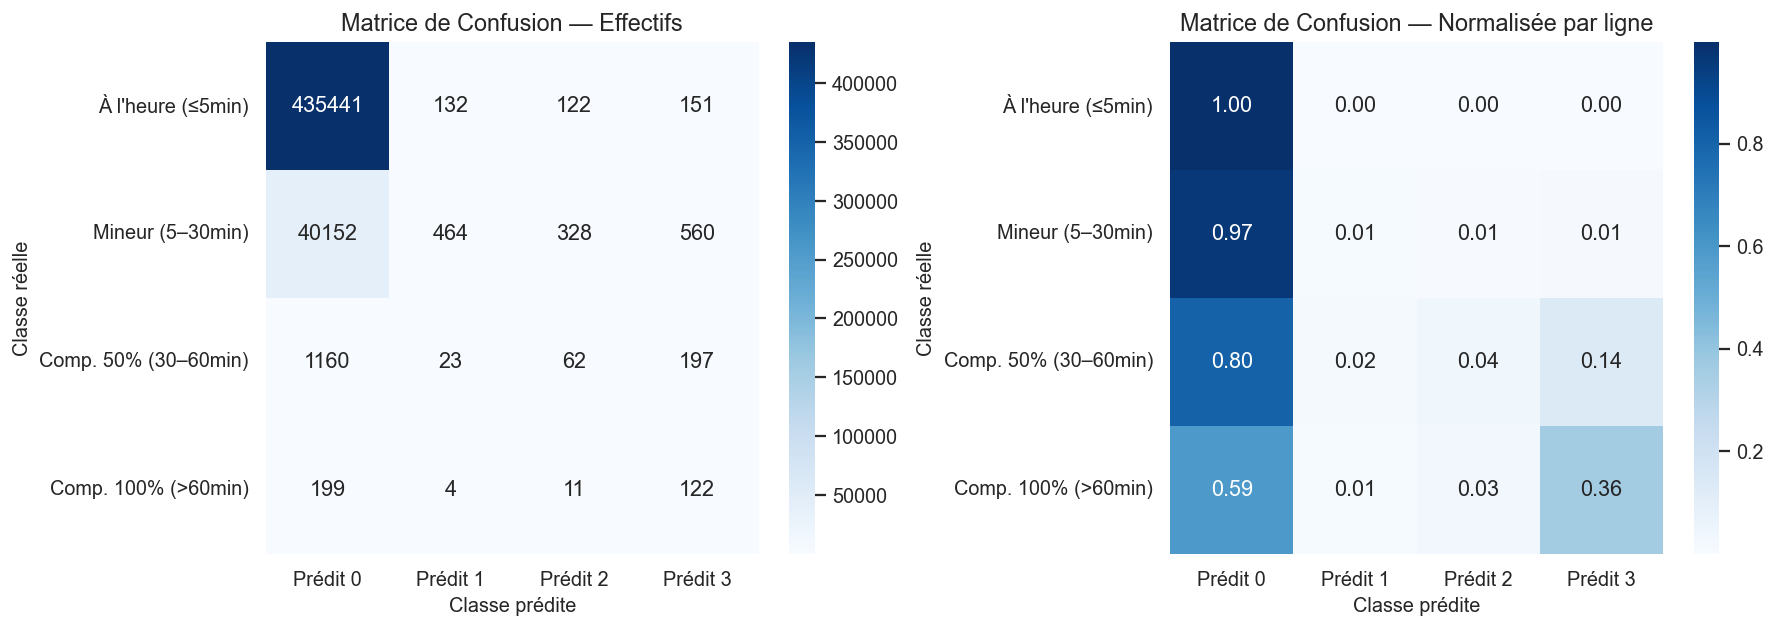

In [ ]:
# Matrice de confusion 
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Prédit {i}' for i in range(4)],
            yticklabels=[CLASS_LABELS[i] for i in range(4)])
axes[0].set_title('Matrice de Confusion — Effectifs')
axes[0].set_ylabel('Classe réelle')
axes[0].set_xlabel('Classe prédite')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'Prédit {i}' for i in range(4)],
            yticklabels=[CLASS_LABELS[i] for i in range(4)])
axes[1].set_title('Matrice de Confusion — Normalisée par ligne')
axes[1].set_ylabel('Classe réelle')
axes[1].set_xlabel('Classe prédite')

plt.tight_layout()
plt.savefig('brf_confusion_matrix.png', bbox_inches='tight')
plt.show()

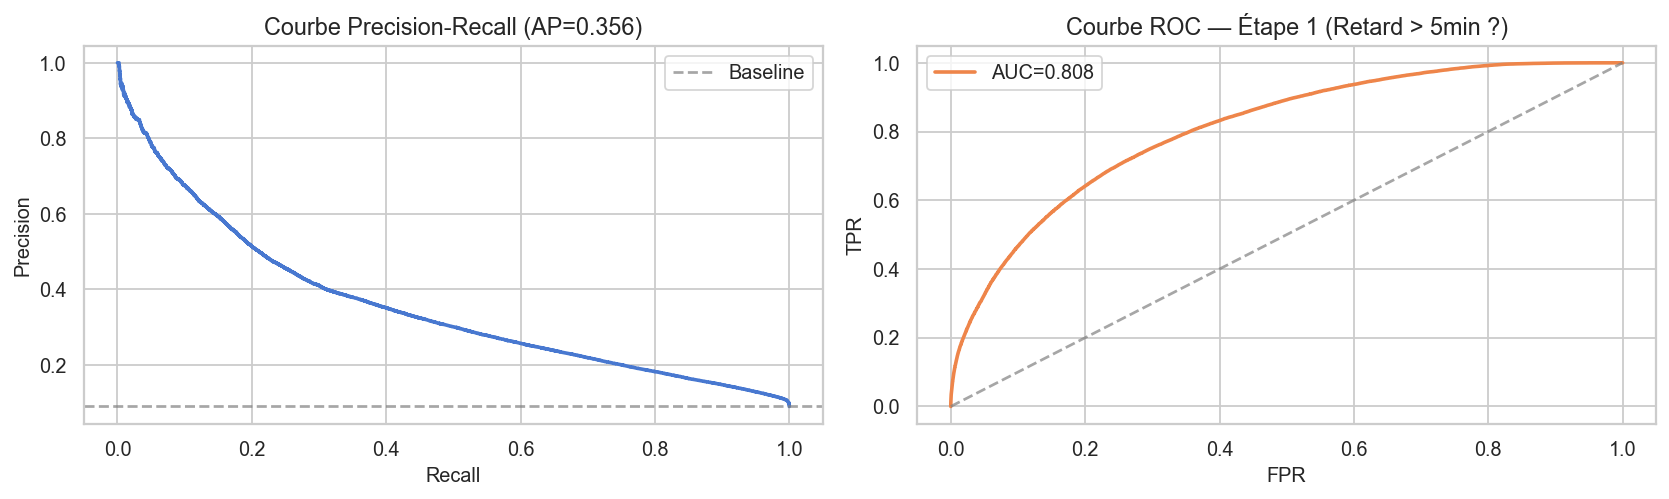

In [ ]:
# Courbe PR et ROC (étape 1) 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PR Curve
prec_arr, rec_arr, _ = precision_recall_curve(y_test_s1, proba_test_s1)
axes[0].plot(rec_arr, prec_arr, color=PALETTE[0], lw=2)
axes[0].axhline(y_test_s1.mean(), color='gray', linestyle='--', alpha=0.7, label='Baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Courbe Precision-Recall (AP={ap_binary:.3f})')
axes[0].legend()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_s1, proba_test_s1)
axes[1].plot(fpr, tpr, color=PALETTE[1], lw=2, label=f'AUC={auc_binary:.3f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Courbe ROC — Étape 1 (Retard > 5min ?)')
axes[1].legend()

plt.tight_layout()
plt.savefig('brf_pr_roc.png', bbox_inches='tight')
plt.show()

---
## 15. Évaluation Financière (Barèmes NS réels)

### Logique d'évaluation

On calcule le **coût financier réel** engendré par les erreurs de prédiction, selon la politique NS :

- **Faux Négatif classe 2** (retard 30-60 min non détecté) → compensation 50% du billet non provisionnée  
- **Faux Négatif classe 3** (retard >60 min non détecté) → compensation 100% du billet non provisionnée  
- **Faux Positif** (alerte inutile) → coût opérationnel de l'alerte

La **baseline naïve** est un modèle qui prédit toujours « à l'heure » (classe 0) (c'est le coût maximal sans modèl)

In [ ]:
# Coûts sur le test set 
cost_model   = business_cost(y_test, y_test_pred)
cost_naive_v = naive_cost(y_test)
saving       = cost_naive_v - cost_model
saving_pct   = saving / cost_naive_v * 100

print('═'*72)
print('  BRF CASCADE — ÉVALUATION FINANCIÈRE (TEST SET)')
print('  Barèmes NS : 50% billet si 30-59min | 100% billet si ≥60min')
print('═'*72)
print(f'  Prix moyen billet utilisé       : €{AVG_TICKET:.2f}')
print(f'  Compensation moyenne cl.2 (50%) : €{COMP_50:,.0f} / service')
print(f'  Compensation moyenne cl.3 (100%): €{COMP_100:,.0f} / service')
print('─'*72)
print(f'  Coût modèle BRF      : €{cost_model:>12,.0f}')
print(f'  Baseline naïve       : €{cost_naive_v:>12,.0f}')
arrow = '↓ ÉCONOMIE ✓' if saving > 0 else '↑ SURCOÛT ✗'
print(f'  Économie réalisée    : €{saving:>+12,.0f}  ({saving_pct:.1f}%)  {arrow}')
print('─'*72)

# Extrapolation annuelle
test_days    = (df_test['Service:Date'].max() - df_test['Service:Date'].min()).days + 1
annual_scale = 365 / max(test_days, 1)
print(f'  Période test         : {test_days} jours')
print(f'  Économie annualisée  : €{saving * annual_scale:>+12,.0f}')
print('═'*72)

# Détail par type d'erreur
print()
print('Détail des erreurs coûteuses :')
fn_c2 = ((y_test==2) & (y_test_pred < 2)).sum()
fn_c3 = ((y_test==3) & (y_test_pred < 3)).sum()
fp_all = ((y_test_pred > y_test)).sum()
print(f'  FN classe 2 (retard 30-60 min non détecté) : {fn_c2:,}  → €{fn_c2*COMP_50:,.0f} de comp. non provisionnée')
print(f'  FN classe 3 (retard >60 min non détecté)   : {fn_c3:,}  → €{fn_c3*COMP_100:,.0f} de comp. non provisionnée')
print(f'  FP total   (alertes inutiles)               : {fp_all:,}  → €{fp_all*FP_COST:,.0f} de coûts opérationnels')

════════════════════════════════════════════════════════════════════════
  BRF CASCADE — ÉVALUATION FINANCIÈRE (TEST SET)
  Barèmes NS : 50% billet si 30-59min | 100% billet si ≥60min
════════════════════════════════════════════════════════════════════════
  Prix moyen billet utilisé       : €16.07
  Compensation moyenne cl.2 (50%) : €482 / service
  Compensation moyenne cl.3 (100%): €964 / service
────────────────────────────────────────────────────────────────────────
  Coût modèle BRF      : €     845,847
  Baseline naïve       : €   1,019,143
  Économie réalisée    : €    +173,295  (17.0%)  ↓ ÉCONOMIE ✓
────────────────────────────────────────────────────────────────────────
  Période test         : 353 jours
  Économie annualisée  : €    +179,186
════════════════════════════════════════════════════════════════════════

Détail des erreurs coûteuses :
  FN classe 2 (retard 30-60 min non détecté) : 1,183  → €570,315 de comp. non provisionnée
  FN classe 3 (retard >60 min non détecté)

---
## 16. Feature Importance

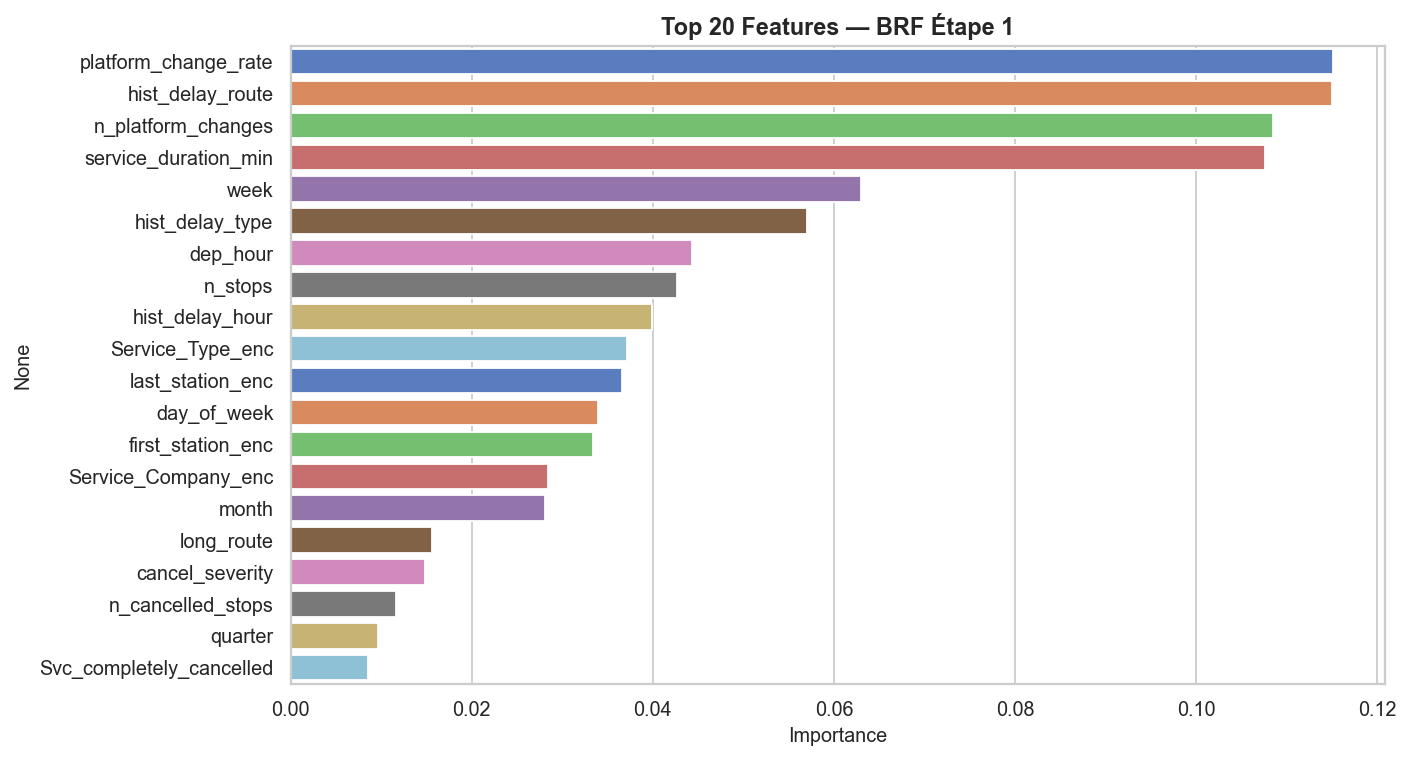

Top 10 features :
  platform_change_rate                : 0.1152
  hist_delay_route                    : 0.1150
  n_platform_changes                  : 0.1086
  service_duration_min                : 0.1077
  week                                : 0.0630
  hist_delay_type                     : 0.0570
  dep_hour                            : 0.0443
  n_stops                             : 0.0427
  hist_delay_hour                     : 0.0400
  Service_Type_enc                    : 0.0371


In [21]:
fi = pd.Series(model_s1.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x=fi.values[:20], y=fi.index[:20], palette='muted', orient='h')
plt.title('Top 20 Features — BRF Étape 1', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('brf_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features :')
for feat, imp in fi.head(10).items():
    print(f'  {feat:<35} : {imp:.4f}')

In [24]:
import joblib

joblib.dump(model_s1,       'brf_model_s1.pkl')
joblib.dump(model_s2, 'brf_model_s2.pkl')
joblib.dump(model_s3,       'brf_model_s3.pkl')

joblib.dump({
    'thr_s1'  : thr_s1,
    'thr_s2'  : thr_s2,
    'thr_s3'  : thr_s3,
    'features': FEATURES,
    'avg_ticket': AVG_TICKET,
    'comp_50' : COMP_50,
    'comp_100': COMP_100,
}, 'brf_config.pkl')

print('✓ Modèles sauvegardés')

✓ Modèles sauvegardés
